# Hydroxyl anions and radicals in water
Simulations were run at 350 K for 100 ps.

The systems contained 39 water molecules and one OH-/OH* unit.

The OH- system has a -1 charge and is overall a singlet spin state. The OH* is charge neutral but has an overall doublet spin state.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os
import tol_colors as tc
cset = tc.bright

import utils.helper_funcs as hf
#import utils.thermo_funcs as tf


from ase.io import read

data_path = '../data'

POLAR_paths = {
    'OH$^-$(aq)':'/MACE-POLAR-1-M/39_water_OH/charged_singlet/',
    'OH$^*$(aq)':'/MACE-POLAR-1-M/39_water_OH/neutral_doublet/',
}

colour_map = {
    'OH$^-$(aq)':cset.red,
    'OH$^*$(aq)':cset.blue,
}

plt.rcParams.update({'font.size': 14})

# H-[O]...H structure

In [9]:
POLAR_HO_H_rdf_data = hf.load_data(POLAR_paths, root_dir=data_path, fname='travis/rdf_HO_H2O_[Or_Ho].csv')

Loading data for 'OH$^-$(aq)' from '../data/MACE-POLAR-1-M/39_water_OH/charged_singlet/travis/rdf_HO_H2O_[Or_Ho].csv'
Loading data for 'OH$^*$(aq)' from '../data/MACE-POLAR-1-M/39_water_OH/neutral_doublet/travis/rdf_HO_H2O_[Or_Ho].csv'


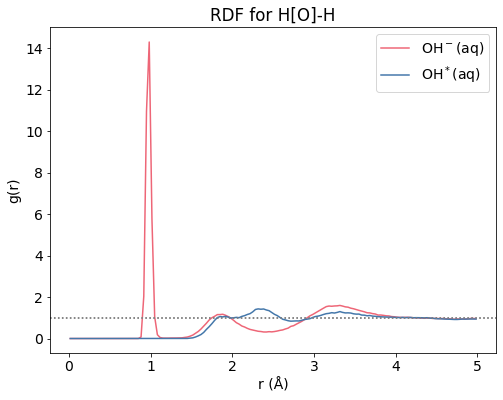

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title(f'RDF for H[O]-H')
for i, key in enumerate(POLAR_HO_H_rdf_data):
    r = POLAR_HO_H_rdf_data[key]['# Distance / pm']/100
    ax.set_xlabel('r (Å)')
    ax.set_ylabel('g(r)')
   # ax.set_xlim(2, max(r))

    ax.plot(r, POLAR_HO_H_rdf_data[key]['  g(r)'], color=colour_map[key], label=key)
    rmax = POLAR_HO_H_rdf_data[key]['# Distance / pm'].max()/100

    ax.legend()
    ax.axhline(1, 0, rmax, color='gray', linestyle=':')
plt.show()

# Thermodynamic properties

## MACE-MP-0

## MACE-POLAR-1-M

In [23]:
POLAR_thermo_df = hf.cached_thermo_props(
    'results/OH/POLAR_thermo_props.json',
    POLAR_paths, 
    data_path, 
    temperature=350.0, 
    correlation_times={"density": 60, "heat_capacity": 60, "compressibility": 60, "bulk_modulus": 60, "thermal_expansion": 60},
    block_factor=10,
)
POLAR_thermo_df

Loaded thermodynamic properties from results/OH/POLAR_thermo_props.json


# Proton hopping analysis
Hop rate is in hops/ps, and residence time is in ps.

## MACE-POLAR-1-M

In [22]:
POLAR_hop_df = hf.cached_hop_props(
    'results/OH/POLAR_hop_props-corrframes_100.json',
    POLAR_paths, 
    data_path, 
    correlation_times={"hop_rate": 100, "residence_time": 100}, # hop_rate and residence_time are the only properties we calculate here, so we only need to specify correlation times for those
    block_factor=5,
    cutoff=1.25, # in Å, this is the cutoff we use to determine whether a hop has occurred or not. We can adjust this if we find that it's not capturing all the hops correctly.
)
POLAR_hop_df

Loaded proton hopping properties from results/OH/POLAR_hop_props-corrframes_100.json


In [20]:
POLAR_hop_df = hf.cached_hop_props(
    'results/OH/POLAR_hop_props-full.json',
    POLAR_paths, 
    data_path, 
    correlation_times=None, # hop_rate and residence_time are the only properties we calculate here, so we only need to specify correlation times for those
    use_blocks=False, # since we're using the full trajectory, we don't need to use blocks to estimate the errors, we can just use the full trajectory
    cutoff=1.25, # in Å, this is the cutoff we use to determine whether a hop has occurred or not. We can adjust this if we find that it's not capturing all the hops correctly.
)
POLAR_hop_df

Loaded proton hopping properties from results/OH/POLAR_hop_props-full.json
